##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [3]:
# Cell 1: Import Libraries
import numpy as np
import keras_hub
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
# Cell 2: Load ViTImageClassifier (without preprocessor)
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    preprocessor=None
)

100%|██████████| 3.46k/3.46k [00:00<00:00, 1.36MB/s]


100%|██████████| 331M/331M [00:16<00:00, 20.8MB/s] 


100%|██████████| 328M/328M [00:18<00:00, 18.9MB/s] 


In [5]:
# Cell 3: Load ImageNet class names
import urllib.request

imagenet_classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
urllib.request.urlretrieve(imagenet_classes_url, "imagenet_classes.txt")

with open("imagenet_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

print(f"Total classes: {len(class_names)}")
print(f"First 10 classes: {class_names[:10]}")

Total classes: 1000
First 10 classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


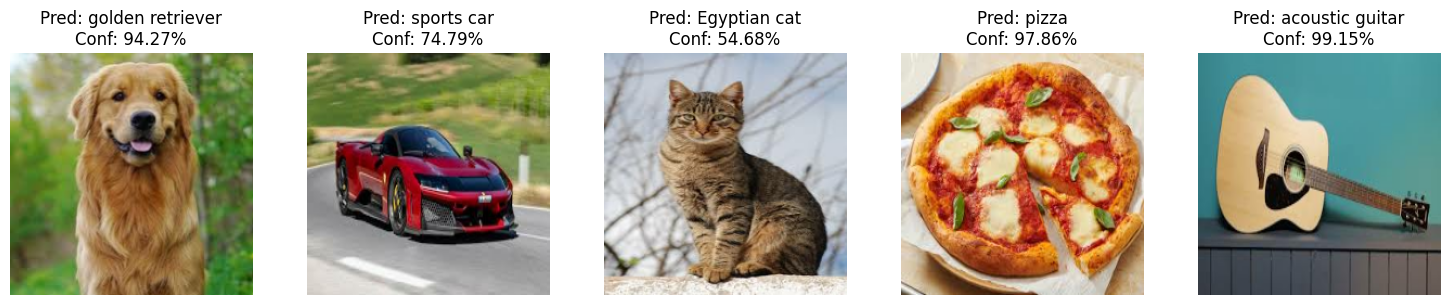

In [6]:
# Cell 4: Load images and predict
image_files = {
    "golden_retriever.jpg": "golden retriever",
    "sports_car.jpg": "sports car",
    "tabby_cat.jpg": "tabby cat",
    "pizza.jpg": "pizza",
    "acoustic_guitar.jpg": "acoustic guitar"
}

results = []
plt.figure(figsize=(15, 3))

for i, (filename, true_label) in enumerate(image_files.items()):
    img = tf.io.read_file(filename)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0  # manual normalization like the lab

    img_batch = tf.expand_dims(img, axis=0)
    predictions = model.predict(img_batch)

    predicted_index = np.argmax(predictions, axis=-1)[0]
    predicted_label = class_names[predicted_index]
    confidence = tf.nn.softmax(predictions[0])[predicted_index].numpy()

    correct = "Yes" if true_label.lower() in predicted_label.lower() or predicted_label.lower() in true_label.lower() else "Check"

    results.append({
        "file": filename,
        "predicted": predicted_label,
        "true_label": true_label,
        "confidence": confidence,
        "correct": correct
    })

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.numpy())
    plt.title(f"Pred: {predicted_label}\nConf: {confidence:.2%}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Cell 5: Print results summary
print(f"{'Image File':<25} {'Predicted Label':<25} {'True Label':<25} {'Confidence':<12} {'Correct?'}")
print("-" * 100)
for r in results:
    print(f"{r['file']:<25} {r['predicted']:<25} {r['true_label']:<25} {r['confidence']:<12.2%} {r['correct']}")

Image File                Predicted Label           True Label                Confidence   Correct?
----------------------------------------------------------------------------------------------------
golden_retriever.jpg      golden retriever          golden retriever          94.27%       Yes
sports_car.jpg            sports car                sports car                74.79%       Yes
tabby_cat.jpg             Egyptian cat              tabby cat                 54.68%       Check
pizza.jpg                 pizza                     pizza                     97.86%       Yes
acoustic_guitar.jpg       acoustic guitar           acoustic guitar           99.15%       Yes
